# Лабораторная работа №1
## Разведочный анализ данных. Исследование и визуализация данных

**Цель лабораторной работы:** изучение различных методов визуализации данных на примере набора данных из библиотеки Scikit-learn.

## Описание задания

В рамках лабораторной работы необходимо выбрать набор данных, выполнить его первичный анализ, исследовать основные характеристики, построить визуализации и проанализировать корреляцию признаков.

В качестве набора данных выбран **Wine dataset** из библиотеки **Scikit-learn**. Данный датасет удобен для разведочного анализа, так как содержит числовые признаки, небольшой объем данных и не содержит пропусков.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine

In [5]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## Описание набора данных

Набор данных **Wine** содержит результаты химического анализа образцов вина, полученных из винограда трех различных сортов.

Каждая строка таблицы представляет собой отдельный образец вина, а столбцы содержат числовые характеристики этого образца, например:
- содержание алкоголя;
- яблочной кислоты;
- магния;
- фенолов;
- флавоноидов;
- интенсивности окраски и других параметров.

Также в датасете присутствует целевая переменная `target`, которая показывает, к какому из трех классов относится образец вина.

Данный набор данных выбран для лабораторной работы, так как он:
- имеет небольшой размер;
- не содержит пропусков;
- хорошо подходит для построения графиков;
- позволяет выполнить корреляционный анализ признаков.

In [10]:
wine = load_wine()

df = pd.DataFrame(wine.data, columns=wine.feature_names)
df["target"] = wine.target

## Первичный просмотр данных

На данном этапе выполним загрузку данных в DataFrame и посмотрим на первые строки таблицы.

In [11]:
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## Основные характеристики датасета

Сначала определим количество строк и столбцов в наборе данных.

In [12]:
df.shape

(178, 14)

Результат показывает размерность датасета: количество наблюдений и количество признаков.

In [13]:
df.columns.tolist()

['alcohol',
 'malic_acid',
 'ash',
 'alcalinity_of_ash',
 'magnesium',
 'total_phenols',
 'flavanoids',
 'nonflavanoid_phenols',
 'proanthocyanins',
 'color_intensity',
 'hue',
 'od280/od315_of_diluted_wines',
 'proline',
 'target']

In [14]:
df.dtypes

alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
target                            int64
dtype: object

Все признаки в выбранном наборе данных являются числовыми, что удобно для построения статистических характеристик, графиков и матрицы корреляции.

## Проверка пропусков

Для корректного анализа необходимо проверить, есть ли в наборе данных пропущенные значения.

In [15]:
df.isnull().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

По результатам проверки видно, что пропущенные значения в датасете отсутствуют.

## Описательная статистика

Вычислим основные статистические характеристики признаков:
- количество значений;
- среднее значение;
- стандартное отклонение;
- минимальное и максимальное значения;
- квартили.

In [16]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


По таблице описательной статистики можно оценить диапазоны значений признаков, разброс данных и возможные различия масштабов между отдельными признаками.

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

## Распределение объектов по классам

Посмотрим, как объекты распределены по целевым классам.

In [19]:
df["target"].value_counts()

target
1    71
0    59
2    48
Name: count, dtype: int64

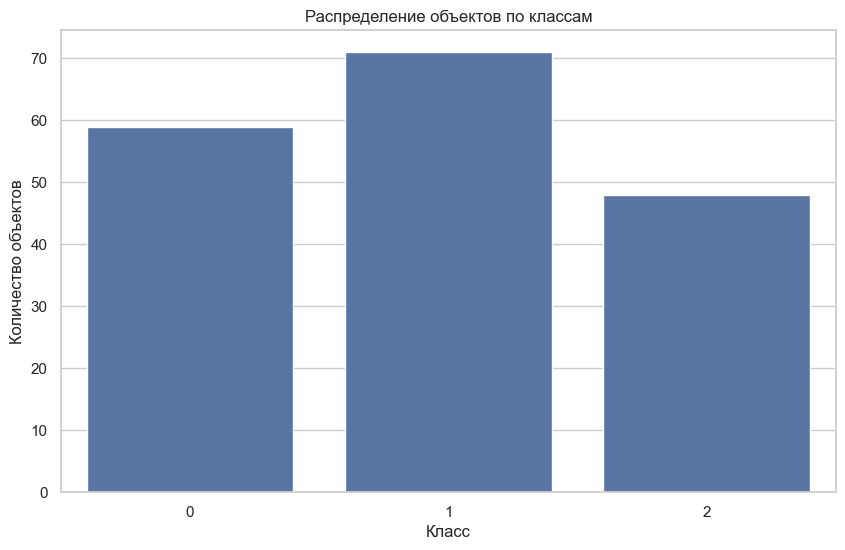

In [18]:
sns.countplot(data=df, x="target")
plt.title("Распределение объектов по классам")
plt.xlabel("Класс")
plt.ylabel("Количество объектов")
plt.show()

По диаграмме видно, что объекты распределены по трем классам достаточно близко по количеству, хотя полного равенства между ними нет.

## Визуальное исследование датасета

Для изучения распределений признаков построим гистограммы для нескольких переменных.

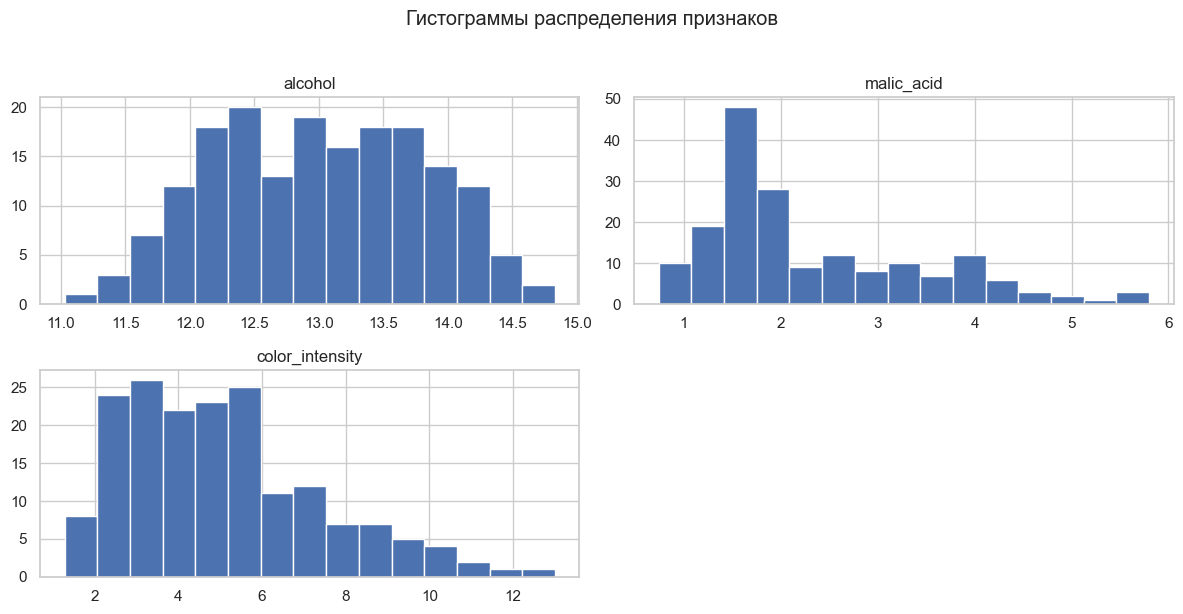

In [20]:
df[["alcohol", "malic_acid", "color_intensity"]].hist(figsize=(12, 6), bins=15)
plt.suptitle("Гистограммы распределения признаков", y=1.02)
plt.tight_layout()
plt.show()

По гистограммам можно заметить, что признаки имеют разные формы распределения.
Например, некоторые признаки распределены более равномерно, а некоторые имеют выраженную асимметрию.
Это говорит о том, что характеристики образцов вина существенно различаются между собой.

## Анализ выбросов

Для оценки разброса значений и возможных выбросов построим диаграммы размаха.

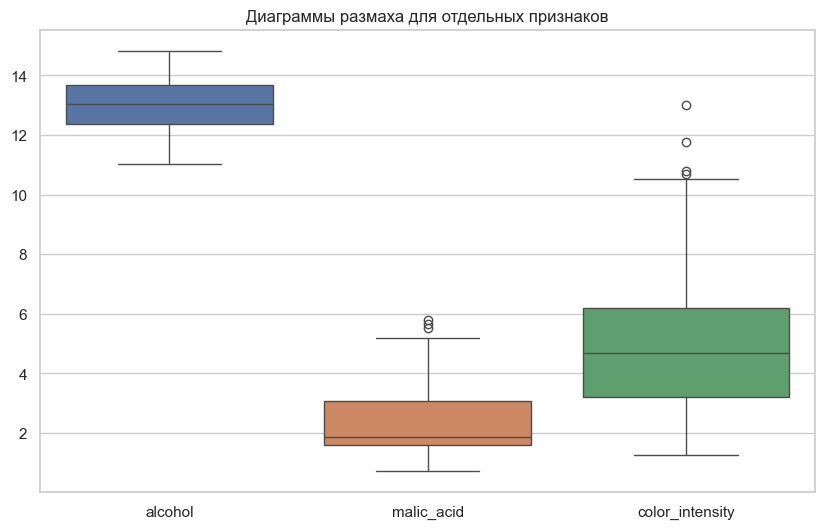

In [21]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[["alcohol", "malic_acid", "color_intensity"]])
plt.title("Диаграммы размаха для отдельных признаков")
plt.show()

Диаграммы размаха позволяют увидеть медиану, межквартильный размах и возможные выбросы.
Можно заметить, что для некоторых признаков присутствуют значения, выходящие за пределы основного диапазона.

## Исследование взаимосвязи признаков

Построим диаграмму рассеяния для двух признаков и выделим классы цветом.

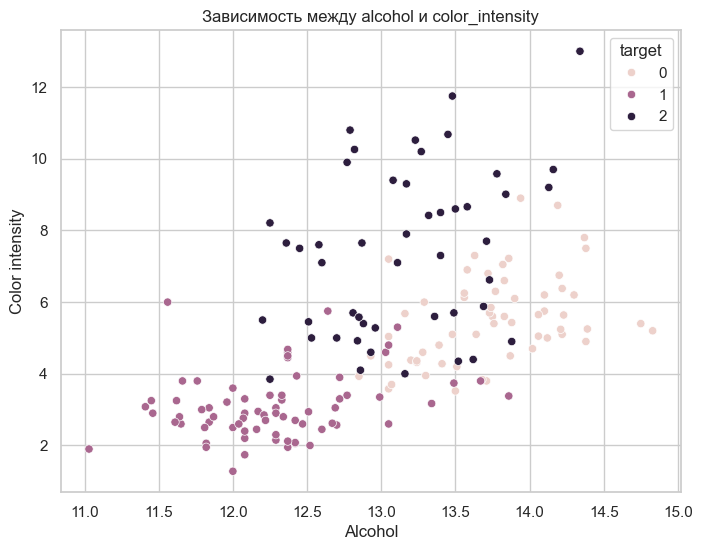

In [22]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="alcohol", y="color_intensity", hue="target")
plt.title("Зависимость между alcohol и color_intensity")
plt.xlabel("Alcohol")
plt.ylabel("Color intensity")
plt.show()

Диаграмма рассеяния показывает, что между признаками `alcohol` и `color_intensity` наблюдается определенная зависимость.
Также можно заметить частичное разделение объектов по классам, что говорит о полезности данных признаков для анализа.

## Попарный анализ признаков

Для более детального визуального исследования выберем несколько признаков и построим попарные графики.

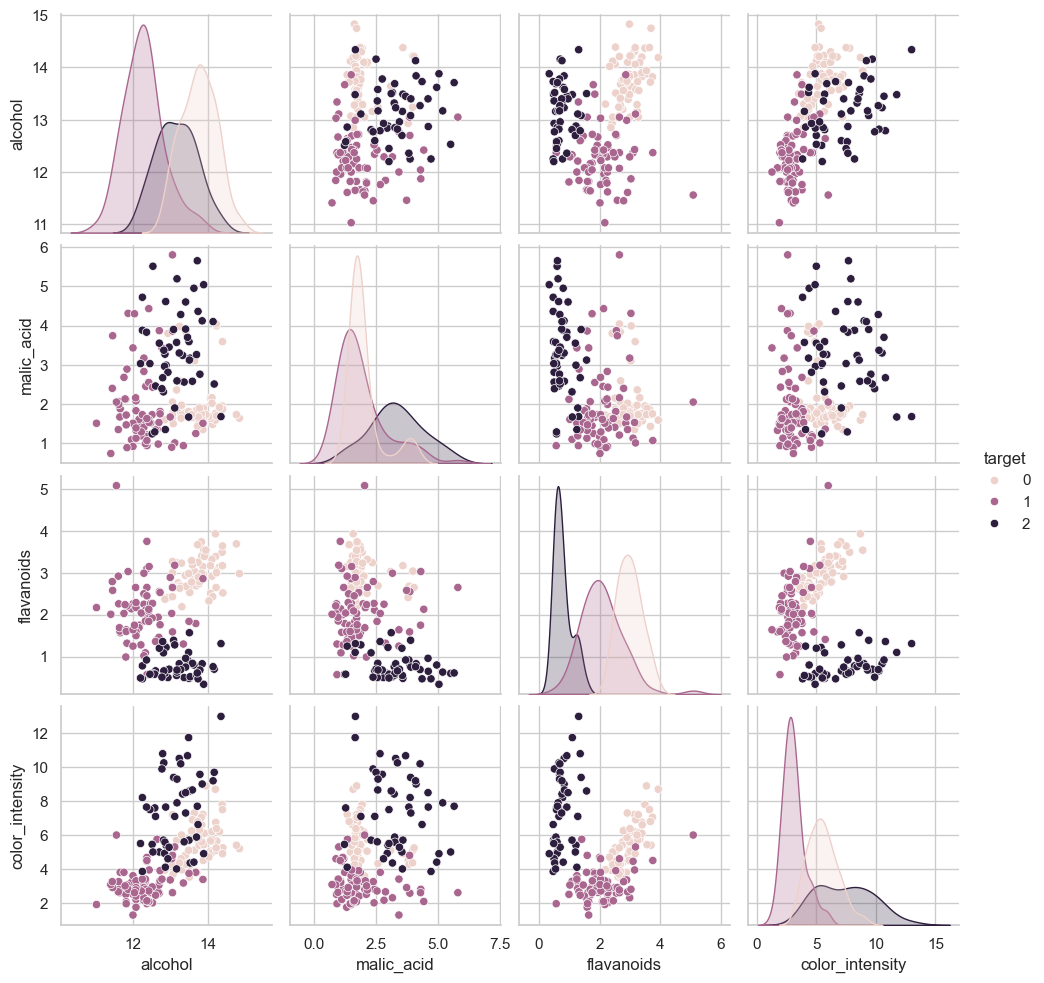

In [23]:
selected_columns = ["alcohol", "malic_acid", "flavanoids", "color_intensity", "target"]
sns.pairplot(df[selected_columns], hue="target")
plt.show()

Попарные графики позволяют увидеть распределения признаков на диагонали и взаимосвязи между ними вне диагонали.
По данным графикам можно заметить, что некоторые пары признаков лучше разделяют классы, чем другие.

## Информация о корреляции признаков

Для исследования линейной зависимости между признаками построим матрицу корреляции.

In [26]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
alcohol,1.000000,0.094397,0.211545,-0.310235,0.270798,0.289101,0.236815,-0.155929,0.136698,0.546364,-0.071747,0.072343,0.643720,-0.328222
malic_acid,0.094397,1.000000,0.164045,0.288500,-0.054575,-0.335167,-0.411007,0.292977,-0.220746,0.248985,-0.561296,-0.368710,-0.192011,0.437776
ash,0.211545,0.164045,1.000000,0.443367,0.286587,0.128980,0.115077,0.186230,0.009652,0.258887,-0.074667,0.003911,0.223626,-0.049643
alcalinity_of_ash,-0.310235,0.288500,0.443367,1.000000,-0.083333,-0.321113,-0.351370,0.361922,-0.197327,0.018732,-0.273955,-0.276769,-0.440597,0.517859
magnesium,0.270798,-0.054575,0.286587,-0.083333,1.000000,0.214401,0.195784,-0.256294,0.236441,0.199950,0.055398,0.066004,0.393351,-0.209179
total_phenols,0.289101,-0.335167,0.128980,-0.321113,0.214401,1.000000,0.864564,-0.449935,0.612413,-0.055136,0.433681,0.699949,0.498115,-0.719163
flavanoids,0.236815,-0.411007,0.115077,-0.351370,0.195784,0.864564,1.000000,-0.537900,0.652692,-0.172379,0.543479,0.787194,0.494193,-0.847498
nonflavanoid_phenols,-0.155929,0.292977,0.186230,0.361922,-0.256294,-0.449935,-0.537900,1.000000,-0.365845,0.139057,-0.262640,-0.503270,-0.311385,0.489109
proanthocyanins,0.136698,-0.220746,0.009652,-0.197327,0.236441,0.612413,0.652692,-0.365845,1.000000,-0.025250,0.295544,0.519067,0.330417,-0.499130
color_intensity,0.546364,0.248985,0.258887,0.018732,0.199950,-0.055136,-0.172379,0.139057,-0.025250,1.000000,-0.521813,-0.428815,0.316100,0.265668


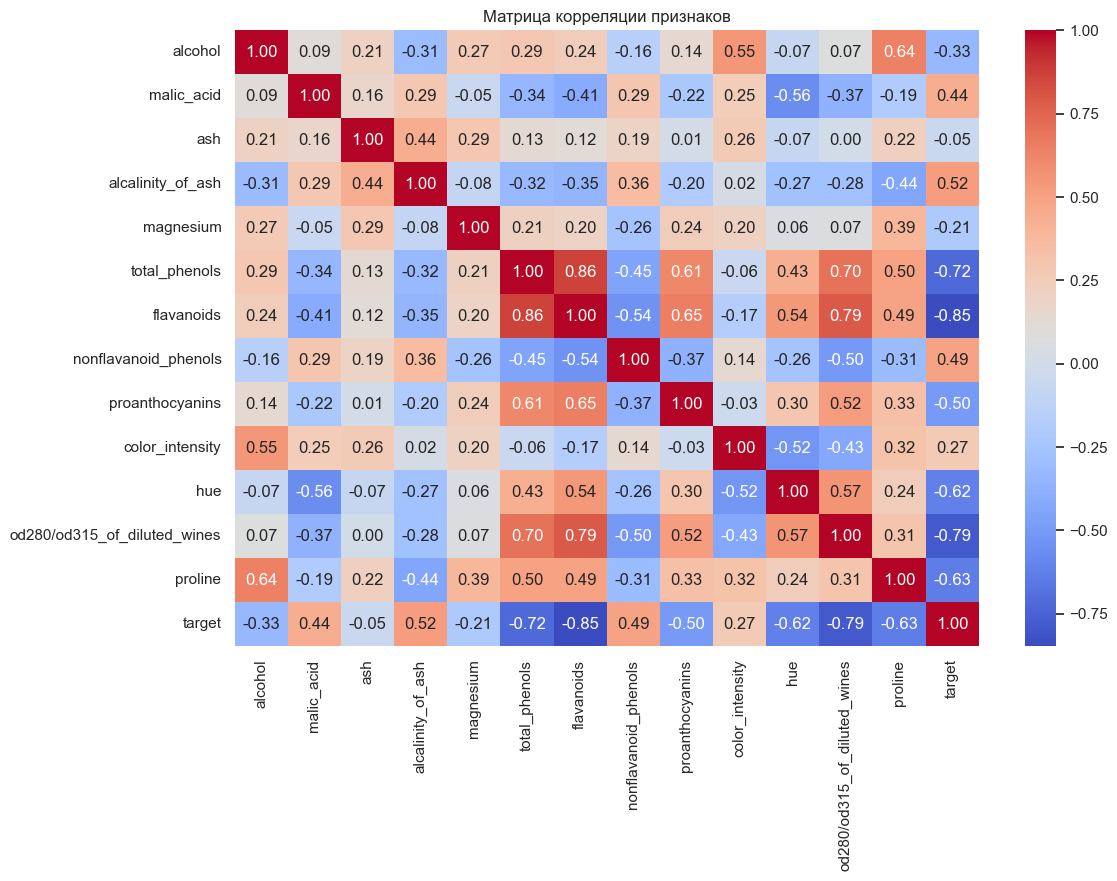

In [27]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Матрица корреляции признаков")
plt.show()

По тепловой карте корреляции можно сделать следующие выводы:

- между некоторыми признаками наблюдается сильная положительная корреляция;
- между отдельными признаками присутствует отрицательная корреляция;
- часть признаков взаимосвязана достаточно сильно, что может указывать на частичное дублирование информации;
- целевая переменная также по-разному связана с отдельными признаками.

Корреляционный анализ помогает понять структуру датасета и выявить наиболее значимые зависимости между признаками.

## Дополнительный анализ корреляций

Для удобства можно отдельно посмотреть наиболее сильные корреляции между признаками.

In [28]:
corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
corr_pairs.drop_duplicates().head(20)

alcohol                       alcohol                         1.000000
flavanoids                    total_phenols                   0.864564
od280/od315_of_diluted_wines  flavanoids                      0.787194
                              total_phenols                   0.699949
flavanoids                    proanthocyanins                 0.652692
proline                       alcohol                         0.643720
total_phenols                 proanthocyanins                 0.612413
hue                           od280/od315_of_diluted_wines    0.565468
alcohol                       color_intensity                 0.546364
hue                           flavanoids                      0.543479
od280/od315_of_diluted_wines  proanthocyanins                 0.519067
target                        alcalinity_of_ash               0.517859
total_phenols                 proline                         0.498115
proline                       flavanoids                      0.494193
nonfla

Полученные значения позволяют выделить пары признаков с наиболее сильной линейной связью.

## Выводы

В ходе выполнения лабораторной работы был проведен разведочный анализ данных для набора данных **Wine** из библиотеки **Scikit-learn**.

В процессе работы были выполнены следующие действия:
- загружен и преобразован в DataFrame выбранный датасет;
- исследованы основные характеристики набора данных;
- выполнена проверка типов данных и пропусков;
- рассчитаны описательные статистики;
- построены графики распределения признаков;
- выполнен визуальный анализ данных;
- исследованы корреляции между признаками.

По результатам анализа можно сделать вывод, что датасет является удобным для разведочного анализа:
- он не содержит пропусков;
- содержит только числовые признаки;
- позволяет строить наглядные визуализации;
- имеет различия между классами, заметные на графиках;
- содержит признаки с выраженными корреляционными связями.

Таким образом, цель лабораторной работы достигнута: были изучены основные методы визуализации данных и выполнено исследование структуры выбранного набора данных.